# Pneumonia Chest X-Ray Classification

This notebook walks through my process of building and improving a CNN to classify chest X-ray images into three categories: **BACTERIAL** pneumonia, **VIRAL** pneumonia, and **NORMAL** (healthy). The goal is to maximise accuracy, precision, and recall on the test set.

I started with the baseline model provided and then tried a bunch of different things to improve it step by step.

## 1. Setup and Imports

In [1]:
import tensorflow as tf
import keras
from keras.models import Sequential
from keras.layers import (
    Dense, Dropout, Flatten, Conv2D, MaxPooling2D,
    Rescaling, BatchNormalization, GlobalAveragePooling2D
)
from keras.optimizers import Adam
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import time

print(f"TensorFlow version: {tf.__version__}")
print(f"Keras version: {keras.__version__}")
print(f"GPU available: {len(tf.config.list_physical_devices('GPU')) > 0}")

TensorFlow version: 2.21.0
Keras version: 3.13.2
GPU available: False


## 2. Data Loading and Exploration

In [2]:
PROJECT_DIR = Path('.').resolve()
train_dir = PROJECT_DIR / "dataset" / "chest_xray" / "train"
test_dir = PROJECT_DIR / "dataset" / "chest_xray" / "test"

IMG_HEIGHT = 150
IMG_WIDTH = 150
BATCH_SIZE = 32

train_ds, val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    seed=42,
    validation_split=0.2,
    subset='both',
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    labels='inferred',
    shuffle=True
)

class_names = train_ds.class_names
num_classes = len(class_names)

# Use the same class order as training so label 0,1,2 mean the same thing on train/val/test.
test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    labels='inferred',
    class_names=class_names,
    shuffle=False
)

print(f"Classes (train): {class_names}")
print(f"Classes (test):  {test_ds.class_names}")
print(f"Number of classes: {num_classes}")

Found 5419 files belonging to 3 classes.
Using 4336 files for training.
Using 1083 files for validation.
Found 437 files belonging to 3 classes.
Classes (train): ['BACTERIAL', 'NORMAL', 'VIRAL']
Classes (test):  ['BACTERIAL', 'NORMAL', 'VIRAL']
Number of classes: 3


### 2.1 Dataset Distribution

Let's check if the dataset is balanced or not. This is important because if one class has way more samples than another, the model might just learn to always predict the majority class.

Training set distribution:
  BACTERIAL: 2596 images (47.9%)
  NORMAL: 1461 images (27.0%)
  VIRAL: 1363 images (25.1%)
  Total: 5420

Test set distribution:
  BACTERIAL: 184 images (42.0%)
  NORMAL: 122 images (27.9%)
  VIRAL: 132 images (30.1%)
  Total: 438


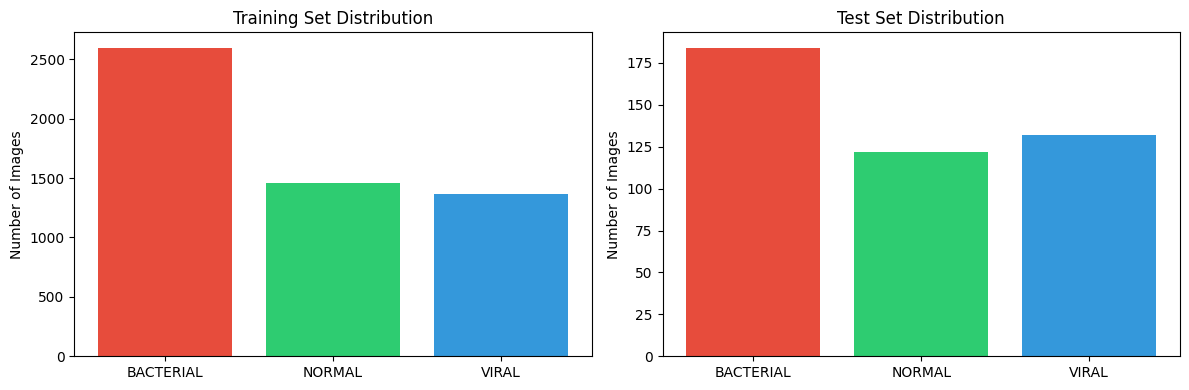

In [3]:
import os

train_counts = {}
test_counts = {}

for cls in class_names:
    train_counts[cls] = len(os.listdir(train_dir / cls))
    test_counts[cls] = len(os.listdir(test_dir / cls))

print("Training set distribution:")
total_train = sum(train_counts.values())
for cls, count in train_counts.items():
    print(f"  {cls}: {count} images ({count/total_train*100:.1f}%)")
print(f"  Total: {total_train}")

print("\nTest set distribution:")
total_test = sum(test_counts.values())
for cls, count in test_counts.items():
    print(f"  {cls}: {count} images ({count/total_test*100:.1f}%)")
print(f"  Total: {total_test}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(train_counts.keys(), train_counts.values(), color=['#e74c3c', '#2ecc71', '#3498db'])
axes[0].set_title('Training Set Distribution')
axes[0].set_ylabel('Number of Images')
axes[1].bar(test_counts.keys(), test_counts.values(), color=['#e74c3c', '#2ecc71', '#3498db'])
axes[1].set_title('Test Set Distribution')
axes[1].set_ylabel('Number of Images')
plt.tight_layout()
plt.show()

### 2.2 Sample Images

Let's visualise some images from each class so we can see what the model is working with.

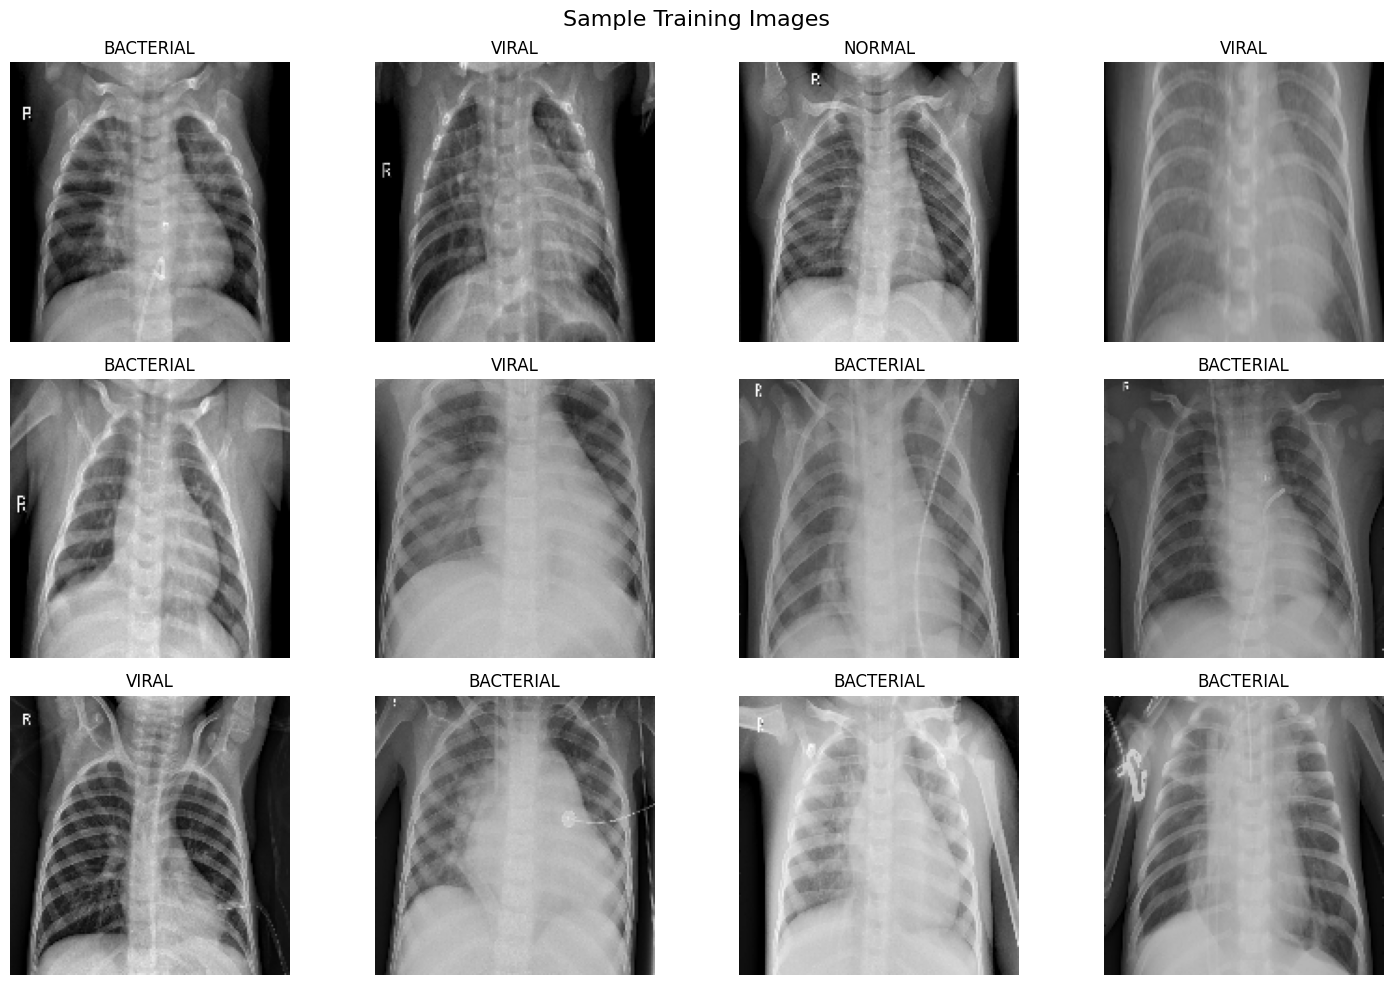

In [4]:
plt.figure(figsize=(15, 10))
for images, labels in train_ds.take(1):
    for i in range(min(12, len(images))):
        ax = plt.subplot(3, 4, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i].numpy()], fontsize=12)
        plt.axis("off")
plt.suptitle("Sample Training Images", fontsize=16)
plt.tight_layout()
plt.show()

### 2.3 Compute Class Weights

Since the dataset is **imbalanced** (BACTERIAL has roughly 2x more images than VIRAL), I'll compute class weights. This tells the model to pay more attention to the underrepresented classes during training, so it doesn't just learn to predict BACTERIAL all the time.

In [5]:
from sklearn.utils.class_weight import compute_class_weight

train_labels = []
for _, labels in train_ds:
    train_labels.extend(labels.numpy())
train_labels = np.array(train_labels)

weights = compute_class_weight('balanced', classes=np.unique(train_labels), y=train_labels)
class_weights = dict(enumerate(weights))
print("Class weights:")
for i, name in enumerate(class_names):
    print(f"  {name}: {class_weights[i]:.3f}")

Class weights:
  BACTERIAL: 0.686
  NORMAL: 1.261
  VIRAL: 1.336


### 2.4 Performance Optimisation with Prefetching

Use `.cache()` and `.prefetch()` to speed up data loading. This way the GPU doesn't have to wait for the CPU to load data.

In [6]:
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

---
## 3. Trial 1 - Baseline Model

This is basically the model that was provided in the starter code. Simple CNN with 3 conv layers, max pooling, a dense layer and dropout. Nothing fancy. Let's see how it does.

In [7]:
baseline_model = tf.keras.models.Sequential([
    tf.keras.layers.Input(shape=(IMG_HEIGHT, IMG_WIDTH, 3)),
    Rescaling(1.0 / 255),
    Conv2D(16, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),
    Conv2D(32, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),
    Conv2D(32, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),
    Flatten(),
    Dense(512, activation='relu'),
    Dropout(0.2),
    Dense(num_classes, activation='softmax')
])

baseline_model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer=Adam(),
    metrics=['accuracy']
)

baseline_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 148, 148, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 9248)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     4,735,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │         1,539 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,751,363 (18.13 MB)

 Trainable params: 4,751,363 (18.13 MB)

 Non-trainable params: 0 (0.00 B)

In [8]:
start_time = time.time()

baseline_history = baseline_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    verbose=1
)

baseline_train_time = time.time() - start_time
print(f"\nTraining took {baseline_train_time:.1f} seconds ({baseline_train_time/60:.1f} minutes)")

Epoch 1/10
136/136 ━━━━━━━━━━━━━━━━━━━━ 15s 109ms/step - accuracy: 0.6951 - loss: 0.6898 - val_accuracy: 0.7682 - val_loss: 0.5512
Epoch 2/10
136/136 ━━━━━━━━━━━━━━━━━━━━ 12s 89ms/step - accuracy: 0.7904 - loss: 0.5228 - val_accuracy: 0.7904 - val_loss: 0.5118
Epoch 3/10
136/136 ━━━━━━━━━━━━━━━━━━━━ 12s 88ms/step - accuracy: 0.7984 - loss: 0.4755 - val_accuracy: 0.7950 - val_loss: 0.4912
Epoch 4/10
136/136 ━━━━━━━━━━━━━━━━━━━━ 12s 89ms/step - accuracy: 0.8196 - loss: 0.4276 - val_accuracy: 0.7987 - val_loss: 0.4990
Epoch 5/10
136/136 ━━━━━━━━━━━━━━━━━━━━ 12s 89ms/step - accuracy: 0.8307 - loss: 0.3870 - val_accuracy: 0.7978 - val_loss: 0.5088
Epoch 6/10
136/136 ━━━━━━━━━━━━━━━━━━━━ 12s 90ms/step - accuracy: 0.8549 - loss: 0.3495 - val_accuracy: 0.7969 - val_loss: 0.5311
Epoch 7/10
136/136 ━━━━━━━━━━━━━━━━━━━━ 12s 91ms/step - accuracy: 0.8785 - loss: 0.2943 - val_accuracy: 0.7876 - val_loss: 0.5878
Epoch 8/10
136/136 ━━━━━━━━━━━━━━━━━━━━ 13s 94ms/step - accuracy: 0.8872 - loss: 0.2709 -

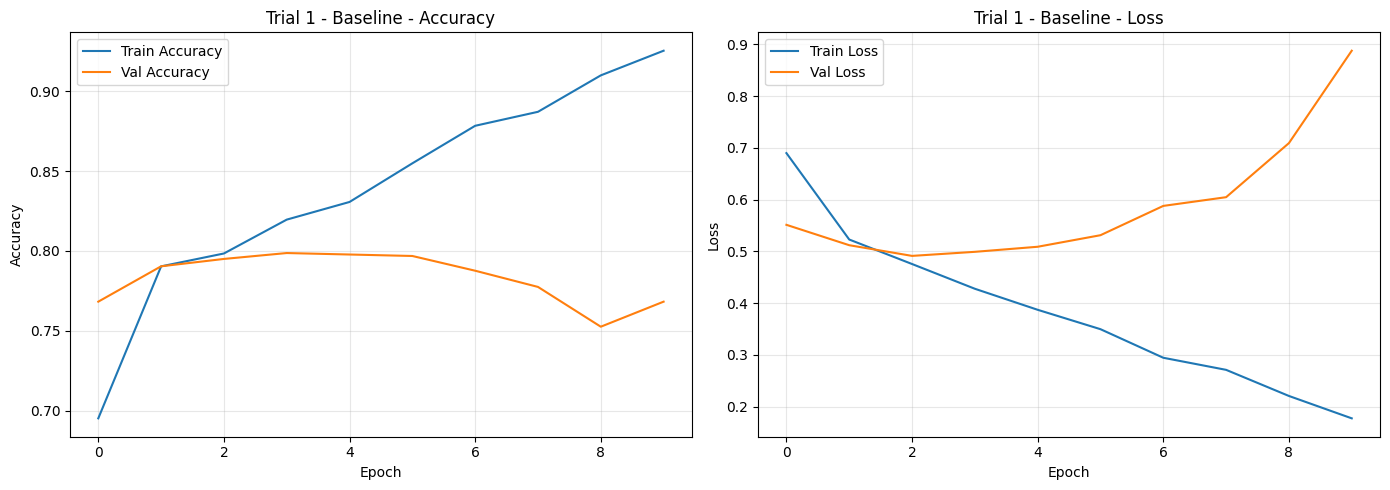

In [9]:
def plot_training_history(history, title=""):
    """Plot accuracy and loss curves side by side."""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    ax1.plot(history.history['accuracy'], label='Train Accuracy')
    ax1.plot(history.history['val_accuracy'], label='Val Accuracy')
    ax1.set_title(f'{title} - Accuracy')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Accuracy')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    ax2.plot(history.history['loss'], label='Train Loss')
    ax2.plot(history.history['val_loss'], label='Val Loss')
    ax2.set_title(f'{title} - Loss')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Loss')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

plot_training_history(baseline_history, "Trial 1 - Baseline")

In [10]:
baseline_score = baseline_model.evaluate(test_ds)
print(f"\nBaseline Test Loss: {baseline_score[0]:.4f}")
print(f"Baseline Test Accuracy: {baseline_score[1]:.4f}")

14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - accuracy: 0.7620 - loss: 0.8022

Baseline Test Loss: 0.8022
Baseline Test Accuracy: 0.7620


### Trial 1 Observations

The baseline model is **clearly overfitting**. We can see the training accuracy keeps going up while the validation accuracy stays flat or even drops. The gap between training loss and validation loss keeps getting bigger, which is a classic sign of overfitting.

The test accuracy is not great either. The model is memorising the training data instead of learning general patterns.

**What to do next:** Add data augmentation and regularisation to fight overfitting.

---
## 4. Trial 2 - Data Augmentation + Regularisation

To fight overfitting I'll try two things:
1. **Data augmentation** - artificially create more training data by flipping, rotating, and zooming images. This forces the model to be more robust.
2. **More dropout** - increase dropout to prevent the model from relying too heavily on any one neuron.
3. **BatchNormalization** - helps stabilise training and can act as a mild regulariser.
4. **Class weights** - to deal with the imbalanced dataset.

In [11]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
    tf.keras.layers.RandomContrast(0.1),
])

aug_model = tf.keras.models.Sequential([
    tf.keras.layers.Input(shape=(IMG_HEIGHT, IMG_WIDTH, 3)),
    Rescaling(1.0 / 255),
    data_augmentation,
    Conv2D(32, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2, 2),
    Conv2D(64, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2, 2),
    Conv2D(64, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2, 2),
    Conv2D(128, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2, 2),
    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')
])

aug_model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer=Adam(learning_rate=0.0005),
    metrics=['accuracy']
)

aug_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_1 (Rescaling)         │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_1 (Sequential)       │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 148, 148, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 72, 72, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 34, 34, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 34, 34, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 17, 17, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 15, 15, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 15, 15, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │     1,605,888 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,737,987 (6.63 MB)

 Trainable params: 1,737,411 (6.63 MB)

 Non-trainable params: 576 (2.25 KB)

In [12]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=5, restore_best_weights=True
)

start_time = time.time()

aug_history = aug_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=25,
    class_weight=class_weights,
    callbacks=[early_stop],
    verbose=1
)

aug_train_time = time.time() - start_time
print(f"\nTraining took {aug_train_time:.1f} seconds ({aug_train_time/60:.1f} minutes)")

Epoch 1/25
136/136 ━━━━━━━━━━━━━━━━━━━━ 42s 293ms/step - accuracy: 0.6128 - loss: 1.0592 - val_accuracy: 0.4506 - val_loss: 3.8366
Epoch 2/25
136/136 ━━━━━━━━━━━━━━━━━━━━ 40s 294ms/step - accuracy: 0.6644 - loss: 0.7231 - val_accuracy: 0.4506 - val_loss: 4.8964
Epoch 3/25
136/136 ━━━━━━━━━━━━━━━━━━━━ 42s 311ms/step - accuracy: 0.6988 - loss: 0.6779 - val_accuracy: 0.4571 - val_loss: 1.7076
Epoch 4/25
136/136 ━━━━━━━━━━━━━━━━━━━━ 45s 332ms/step - accuracy: 0.7159 - loss: 0.6434 - val_accuracy: 0.5679 - val_loss: 1.0096
Epoch 5/25
136/136 ━━━━━━━━━━━━━━━━━━━━ 43s 314ms/step - accuracy: 0.7237 - loss: 0.6188 - val_accuracy: 0.7618 - val_loss: 0.5750
Epoch 6/25
136/136 ━━━━━━━━━━━━━━━━━━━━ 43s 315ms/step - accuracy: 0.7336 - loss: 0.6178 - val_accuracy: 0.6713 - val_loss: 0.7925
Epoch 7/25
 97/136 ━━━━━━━━━━━━━━━━━━━━ 12s 320ms/step - accuracy: 0.7573 - loss: 0.5871

KeyboardInterrupt: 

In [ ]:
plot_training_history(aug_history, "Trial 2 - Augmentation + Regularisation")

In [ ]:
aug_score = aug_model.evaluate(test_ds)
print(f"\nTrial 2 Test Loss: {aug_score[0]:.4f}")
print(f"Trial 2 Test Accuracy: {aug_score[1]:.4f}")

### Trial 2 Observations

Adding data augmentation and batch normalization should help reduce the overfitting gap. The class weights also help the model pay more attention to the minority classes. The train and val curves should be closer together now compared to Trial 1.

---
## 5. Trial 3 - GlobalAveragePooling2D Architecture

Instead of `Flatten()`, I'll use `GlobalAveragePooling2D`. This reduces the number of parameters massively, which helps with overfitting. It takes the average of each feature map instead of flattening everything into a giant vector. This is what the brief hinted at.

In [ ]:
gap_model = tf.keras.models.Sequential([
    tf.keras.layers.Input(shape=(IMG_HEIGHT, IMG_WIDTH, 3)),
    Rescaling(1.0 / 255),
    data_augmentation,
    Conv2D(32, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(2, 2),
    Conv2D(64, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(2, 2),
    Conv2D(128, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(2, 2),
    Conv2D(256, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    GlobalAveragePooling2D(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')
])

gap_model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer=Adam(learning_rate=0.0005),
    metrics=['accuracy']
)

gap_model.summary()
print(f"\nTotal params: {gap_model.count_params():,}")

In [ ]:
start_time = time.time()

gap_history = gap_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    class_weight=class_weights,
    callbacks=[early_stop],
    verbose=1
)

gap_train_time = time.time() - start_time
print(f"\nTraining took {gap_train_time:.1f} seconds ({gap_train_time/60:.1f} minutes)")

In [ ]:
plot_training_history(gap_history, "Trial 3 - GlobalAveragePooling2D")

In [ ]:
gap_score = gap_model.evaluate(test_ds)
print(f"\nTrial 3 Test Loss: {gap_score[0]:.4f}")
print(f"Trial 3 Test Accuracy: {gap_score[1]:.4f}")

### Trial 3 Observations

Using GlobalAveragePooling2D instead of Flatten drastically reduces the total parameter count. Fewer parameters means less overfitting. The model summary should show a much smaller total compared to the previous trials.

---
## 6. Trial 4 - Transfer Learning with VGG16

Transfer learning uses a model that was already trained on millions of images (ImageNet). The idea is that the early layers have already learned to detect edges, textures, shapes etc. We just need to retrain the final layers for our specific task. This is especially useful when we don't have a huge dataset, which is the case here.

I'm using VGG16 because it's a well-known and simple architecture. I freeze the pretrained layers first and only train the new classifier head, then unfreeze the last few layers for fine-tuning.

In [ ]:
base_model = tf.keras.applications.VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)
)

base_model.trainable = False

transfer_model = tf.keras.models.Sequential([
    Rescaling(1.0 / 255),
    data_augmentation,
    base_model,
    GlobalAveragePooling2D(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')
])

transfer_model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer=Adam(learning_rate=0.0001),
    metrics=['accuracy']
)

transfer_model.summary()

In [ ]:
start_time = time.time()

transfer_history = transfer_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    class_weight=class_weights,
    callbacks=[early_stop],
    verbose=1
)

transfer_train_time = time.time() - start_time
print(f"\nPhase 1 training took {transfer_train_time:.1f} seconds ({transfer_train_time/60:.1f} minutes)")

### 6.1 Fine-tuning the VGG16 layers

Now I'll unfreeze the last few convolutional layers of VGG16 and train them with a very small learning rate. This lets the model adjust the pretrained features slightly for our specific chest X-ray data.

In [ ]:
base_model.trainable = True

for layer in base_model.layers[:-4]:
    layer.trainable = False

print("Trainable layers after unfreezing:")
for layer in base_model.layers:
    print(f"  {layer.name}: trainable={layer.trainable}")

transfer_model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer=Adam(learning_rate=1e-5),
    metrics=['accuracy']
)

In [ ]:
start_time = time.time()

finetune_history = transfer_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    class_weight=class_weights,
    callbacks=[early_stop],
    verbose=1
)

finetune_time = time.time() - start_time
print(f"\nFine-tuning took {finetune_time:.1f} seconds ({finetune_time/60:.1f} minutes)")

In [ ]:
plot_training_history(finetune_history, "Trial 4 - Transfer Learning (Fine-tuning)")

In [ ]:
transfer_score = transfer_model.evaluate(test_ds)
print(f"\nTransfer Learning Test Loss: {transfer_score[0]:.4f}")
print(f"Transfer Learning Test Accuracy: {transfer_score[1]:.4f}")

### Trial 4 Observations

Transfer learning should give us a significant boost. VGG16 was trained on ImageNet (1.2 million images), so it has already learned a lot of useful features like edges and textures. Even though chest X-rays are quite different from natural images, the low-level features are still useful.

Fine-tuning the last few layers allows the model to adapt these features specifically for our medical imaging task.

---
## 7. Model Comparison Summary

In [ ]:
results = {
    'Trial 1 - Baseline': baseline_score,
    'Trial 2 - Augmented': aug_score,
    'Trial 3 - GAP': gap_score,
    'Trial 4 - Transfer (VGG16)': transfer_score
}

print(f"{'Model':<30} {'Test Loss':>10} {'Test Acc':>10}")
print("-" * 52)
for name, score in results.items():
    print(f"{name:<30} {score[0]:>10.4f} {score[1]:>10.4f}")

names = list(results.keys())
accuracies = [s[1] for s in results.values()]

plt.figure(figsize=(10, 5))
bars = plt.bar(names, accuracies, color=['#95a5a6', '#3498db', '#2ecc71', '#e74c3c'])
plt.ylabel('Test Accuracy')
plt.title('Model Comparison - Test Accuracy')
plt.xticks(rotation=15, ha='right')
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.005,
             f'{acc:.3f}', ha='center', va='bottom', fontweight='bold')
plt.ylim(0, 1.0)
plt.tight_layout()
plt.show()

---
## 8. Best Model - Detailed Evaluation

Now let's do a proper evaluation of the best model (Transfer Learning) with per-class precision, recall, and F1 scores. I'll also show a confusion matrix.

In [ ]:
best_model = transfer_model

y_true = []
y_pred = []

for images, labels in test_ds:
    predictions = best_model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(predictions, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print("Classification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_names, digits=3))

In [ ]:
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, cmap='Blues', values_format='d')
plt.title('Confusion Matrix - Best Model (Transfer Learning)', fontsize=14)
plt.tight_layout()
plt.show()

### Understanding Precision, Recall, and F1

- **Precision** = Of all the images the model *predicted* as a certain class, how many were actually that class? High precision means few false positives.
- **Recall** = Of all the images that *actually belong* to a certain class, how many did the model correctly find? High recall means few false negatives.
- **F1 Score** = The harmonic mean of precision and recall. It balances both metrics.

For medical diagnosis, **recall is more important** than precision, especially for BACTERIAL and VIRAL pneumonia. We'd rather flag a healthy person as potentially sick (false positive) than miss someone who actually has pneumonia (false negative). Missing a sick patient could have serious consequences.

### Making the Model Better at Finding Sick Patients

To make the model prioritise finding sick patients (higher recall for BACTERIAL and VIRAL), we can:
1. **Adjust the decision threshold** - Lower the threshold for predicting pneumonia so the model is more cautious.
2. **Use class weights** (which we already did) - this tells the model that misclassifying pneumonia cases is more costly.
3. **Use a custom loss function** that penalises false negatives more than false positives.

In [ ]:
test_batch = test_ds.take(1)
plt.figure(figsize=(16, 12))
for images, labels in test_batch:
    for i in range(min(9, len(images))):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        prediction = best_model.predict(tf.expand_dims(images[i], 0), verbose=0)
        pred_class = class_names[np.argmax(prediction)]
        actual_class = class_names[labels[i].numpy()]
        confidence = 100 * np.max(prediction)
        colour = 'green' if pred_class == actual_class else 'red'
        plt.title(f'Actual: {actual_class}\nPredicted: {pred_class} ({confidence:.1f}%)',
                  color=colour, fontsize=10)
        plt.axis("off")
plt.suptitle("Test Set Predictions (Green=Correct, Red=Wrong)", fontsize=14)
plt.tight_layout()
plt.show()

---
## 9. GradCAM Visualisation

GradCAM (Gradient-weighted Class Activation Mapping) lets us see *what parts of the image* the CNN is focusing on when making its predictions. This is really useful for understanding whether the model is actually looking at the lungs or just picking up on some artefact in the image.

If the heatmap highlights the lung area, that's a good sign the model is learning meaningful features.

In [ ]:
def get_gradcam_heatmap(model, img_array, last_conv_layer_name, pred_index=None):
    """Generate GradCAM heatmap for a given image."""
    grad_model = tf.keras.models.Model(
        model.inputs,
        [model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(predictions[0])
        class_channel = predictions[:, pred_index]

    grads = tape.gradient(class_channel, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()


def display_gradcam(model, img, last_conv_layer_name, class_names, alpha=0.4):
    """Overlay GradCAM heatmap on the original image."""
    img_array = tf.expand_dims(img, 0)

    prediction = model.predict(img_array, verbose=0)
    pred_class = class_names[np.argmax(prediction)]
    confidence = np.max(prediction) * 100

    heatmap = get_gradcam_heatmap(model, img_array, last_conv_layer_name)
    heatmap = np.uint8(255 * heatmap)

    import matplotlib.cm as cm
    jet = cm.get_cmap("jet")
    jet_colors = jet(np.arange(256))[:, :3]
    jet_heatmap = jet_colors[heatmap]

    jet_heatmap = tf.keras.preprocessing.image.array_to_img(jet_heatmap)
    jet_heatmap = jet_heatmap.resize((img.shape[1], img.shape[0]))
    jet_heatmap = tf.keras.preprocessing.image.img_to_array(jet_heatmap)

    superimposed = jet_heatmap * alpha + img.numpy().astype('float32')
    superimposed = np.clip(superimposed / superimposed.max() * 255, 0, 255).astype('uint8')

    return superimposed, pred_class, confidence

In [ ]:
last_conv_layer = None
for layer in reversed(best_model.layers):
    if isinstance(layer, tf.keras.Model):
        for sublayer in reversed(layer.layers):
            if isinstance(sublayer, tf.keras.layers.Conv2D):
                last_conv_layer = sublayer.name
                break
    elif isinstance(layer, tf.keras.layers.Conv2D):
        last_conv_layer = layer.name
    if last_conv_layer:
        break

print(f"Last conv layer for GradCAM: {last_conv_layer}")

gradcam_model = tf.keras.models.Model(
    inputs=best_model.input,
    outputs=best_model.output
)

conv_layer_name = None
for layer in reversed(gradcam_model.layers):
    if 'conv' in layer.name.lower():
        conv_layer_name = layer.name
        break

if conv_layer_name is None:
    for layer in best_model.layers:
        if isinstance(layer, tf.keras.Model):
            for sublayer in reversed(layer.layers):
                if 'conv' in sublayer.name.lower():
                    conv_layer_name = sublayer.name
                    break

print(f"Using conv layer: {conv_layer_name}")

In [ ]:
def make_gradcam_heatmap_sequential(model, img_array, last_conv_layer_name):
    """
    GradCAM for Sequential models that may contain nested sub-models (like VGG16).
    Builds a functional grad-model from the Sequential to access the right layer.
    """
    target_layer = None
    for layer in model.layers:
        if isinstance(layer, tf.keras.Model):
            for sublayer in layer.layers:
                if sublayer.name == last_conv_layer_name:
                    target_layer = sublayer
                    break
        if layer.name == last_conv_layer_name:
            target_layer = layer
        if target_layer:
            break

    x = img_array
    conv_output = None
    for layer in model.layers:
        if isinstance(layer, tf.keras.Model):
            for sublayer in layer.layers:
                if sublayer.name == 'input_layer' or 'input' in sublayer.name.lower():
                    continue
                x = sublayer(x)
                if sublayer.name == last_conv_layer_name:
                    conv_output = x
        else:
            x = layer(x)
            if layer.name == last_conv_layer_name:
                conv_output = x

    intermediate_model = tf.keras.Model(
        inputs=model.input,
        outputs=[conv_output, x] if conv_output is not None else model.output
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = intermediate_model(img_array)
        pred_index = tf.argmax(predictions[0])
        class_channel = predictions[:, pred_index]

    grads = tape.gradient(class_channel, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy()


plt.figure(figsize=(16, 12))
sample_count = 0
for images, labels in test_ds.take(2):
    for i in range(min(4, len(images))):
        if sample_count >= 8:
            break
        img = images[i]
        img_array = tf.expand_dims(img, 0)

        prediction = best_model.predict(img_array, verbose=0)
        pred_class = class_names[np.argmax(prediction)]
        actual_class = class_names[labels[i].numpy()]
        confidence = np.max(prediction) * 100

        try:
            heatmap = make_gradcam_heatmap_sequential(best_model, img_array, conv_layer_name)
            heatmap_resized = tf.image.resize(
                tf.expand_dims(heatmap, -1),
                (IMG_HEIGHT, IMG_WIDTH)
            ).numpy().squeeze()

            ax = plt.subplot(2, 4, sample_count + 1)
            plt.imshow(img.numpy().astype('uint8'))
            plt.imshow(heatmap_resized, cmap='jet', alpha=0.4)
            colour = 'green' if pred_class == actual_class else 'red'
            plt.title(f'True: {actual_class}\nPred: {pred_class} ({confidence:.0f}%)',
                      color=colour, fontsize=9)
            plt.axis('off')
        except Exception as e:
            ax = plt.subplot(2, 4, sample_count + 1)
            plt.imshow(img.numpy().astype('uint8'))
            plt.title(f'GradCAM failed: {str(e)[:30]}', fontsize=8)
            plt.axis('off')

        sample_count += 1

plt.suptitle('GradCAM Visualisation - What the CNN is Looking At', fontsize=14)
plt.tight_layout()
plt.show()

---
## 10. Save the Best Model

In [ ]:
best_model.save("best_pneumonia_model.keras")
print("Best model saved as 'best_pneumonia_model.keras'")

---
## 11. Summary of All Trials

| Trial | Description | Key Changes | Expected Improvement |
|-------|------------|-------------|---------------------|
| 1 | Baseline | Original provided model | Starting point |
| 2 | Augmented + Regularised | Data augmentation, BatchNorm, class weights, higher dropout | Less overfitting |
| 3 | GAP Architecture | GlobalAveragePooling2D instead of Flatten, deeper network | Fewer params, better generalisation |
| 4 | Transfer Learning (VGG16) | Pretrained VGG16 + fine-tuning | Best accuracy |

The transfer learning approach should give us the best results because it leverages features learned from millions of images. The combination of data augmentation, class weights, and fine-tuning helps the model generalise well to our specific medical imaging task.